In [ ]:
!git clone https://github.com/Atharva-J740/ML-Pipeline-and-Dashboard-for-Clinical-Prediction-under-Temporal-Shift-in-EHR-Data_Final.git
%cd ML-Pipeline-and-Dashboard-for-Clinical-Prediction-under-Temporal-Shift-in-EHR-Data_Final/project_root

Cloning into 'ML-Pipeline-and-Dashboard-for-Clinical-Prediction-under-Temporal-Shift-in-EHR-Data_Final'...
remote: Enumerating objects: 138, done.
remote: Counting objects: 100% (138/138), done.
remote: Compressing objects: 100% (120/120), done.
remote: Total 138 (delta 21), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (138/138), 1.90 MiB | 9.29 MiB/s, done.
Resolving deltas: 100% (21/21), done.
/content/ML-Pipeline-and-Dashboard-for-Clinical-Prediction-under-Temporal-Shift-in-EHR-Data_Final/project_root/ML-Pipeline-and-Dashboard-for-Clinical-Prediction-under-Temporal-Shift-in-EHR-Data_Final/project_root


In [ ]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 65.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [ ]:
!mkdir -p data/raw/real_dataset/DATA
!pip install gdown
!gdown --folder https://drive.google.com/drive/folders/1dPkA16Cux6zOCpDz32fLY8V66UNKMtB8 -O data/raw/real_dataset/

Retrieving folder contents
Processing file 1eX-3oUwaj6w3veud3ryJd1n2mSd1CFD9 allergies.csv
Processing file 1Gzq0kNuNvraAbZeIKrxsD06Ye-UNsQzw careplans.csv
Processing file 1Pm917oDix8KvjtucIJBTInLu3x3QUHmv claims_transactions.csv
Processing file 18gbRcVheTnr8KZ3pkBWrHs_3jdfAh3EI claims.csv
Processing file 1XeiJzYVUdxiLvPFIvudzv_HtNEP7LMk6 conditions.csv
Processing file 1U0KwH6vL8S_uns8Sjq_4YiJtoymT0bIE devices.csv
Processing file 1kjWhO4N8oD683KjCXSR9YnALqS8uqFLW encounters.csv
Processing file 1bI3aa2g_sqxPBbZcCF7XuIyH2otg3EoK imaging_studies.csv
Processing file 1vSPPA62NJjP8K5GS1WawaXz6TlFn3dPi immunizations.csv
Processing file 1_d3mphqkyz3iwvR6z77G3Nir3eMEAo9x medications.csv
Processing file 1xEgyL3pHc2dk-RCgpiG9qxo0KUYISZnu observations.csv
Processing file 15S4rANP5VZ7TZaYwuyRbw9P4rgO2A-26 organizations.csv
Processing file 1UH3M0oBdJ-B6v132sCmjQswmakH2-8cp patients.csv
Processing file 1UzcVA2YzvA2_miyedqBfKKDNiiUUTaXg payer_transitions.csv
Processing file 1IqXF96y7X555Bf49ASfhjx2V6es

In [ ]:
!python main.py

--- Starting Healthcare ML Pipeline ---
Step 1: Data Ingestion & Feature Engineering...
Step 2: Temporal Splitting...
Saved Dataset 1 to /content/ML-Pipeline-and-Dashboard-for-Clinical-Prediction-under-Temporal-Shift-in-EHR-Data_Final/project_root/ML-Pipeline-and-Dashboard-for-Clinical-Prediction-under-Temporal-Shift-in-EHR-Data_Final/project_root/data/processed/dataset1_historical.csv
Saved Dataset 2 to /content/ML-Pipeline-and-Dashboard-for-Clinical-Prediction-under-Temporal-Shift-in-EHR-Data_Final/project_root/ML-Pipeline-and-Dashboard-for-Clinical-Prediction-under-Temporal-Shift-in-EHR-Data_Final/project_root/data/processed/dataset2_current.csv
Step 3: EDA & Drift Analysis...
/content/ML-Pipeline-and-Dashboard-for-Clinical-Prediction-under-Temporal-Shift-in-EHR-Data_Final/project_root/ML-Pipeline-and-Dashboard-for-Clinical-Prediction-under-Temporal-Shift-in-EHR-Data_Final/project_root/src/eda/analyzer.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated a

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os

project_root = 'project_root'

# Load and display data
d1 = pd.read_csv(f'{project_root}/data/processed/dataset1_historical.csv')
d2 = pd.read_csv(f'{project_root}/data/processed/dataset2_current.csv')
perf = pd.read_csv(f'{project_root}/reports/model_performance.csv')
drift = pd.read_csv(f'{project_root}/reports/drift_analysis.csv')

print("=" * 50)
print("DATASET 1 (Historical)")
print("=" * 50)
print(f"Shape: {d1.shape}")
print(d1.head())

print("\n" + "=" * 50)
print("DATASET 2 (Current)")
print("=" * 50)
print(f"Shape: {d2.shape}")
print(d2.head())

print("\n" + "=" * 50)
print("MODEL PERFORMANCE")
print("=" * 50)
print(perf)

print("\n" + "=" * 50)
print("DRIFT ANALYSIS")
print("=" * 50)
print(drift)

# Display visualizations
print("\n" + "=" * 50)
print("VISUALIZATIONS")
print("=" * 50)

reports_dir = f'{project_root}/reports'
images = [f for f in os.listdir(reports_dir) if f.endswith('.png')]

for img_file in sorted(images)[:5]:  # Show first 5 images
    img_path = os.path.join(reports_dir, img_file)
    print(f"\n{img_file}:")
    img = Image.open(img_path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'project_root/data/processed/dataset1_historical.csv'

In [ ]:
import os

project_root = 'project_root'

print("Checking for required files...")
files_to_check = [
    f'{project_root}/data/processed/dataset1_historical.csv',
    f'{project_root}/data/processed/dataset2_current.csv',
    f'{project_root}/reports/model_performance.csv',
    f'{project_root}/reports/drift_analysis.csv'
]

for file in files_to_check:
    exists = os.path.exists(file)
    print(f"{'✅' if exists else '❌'} {file}")

Checking for required files...
❌ project_root/data/processed/dataset1_historical.csv
❌ project_root/data/processed/dataset2_current.csv
❌ project_root/reports/model_performance.csv
❌ project_root/reports/drift_analysis.csv


In [ ]:
import os
import sys

# Change to project root
os.chdir('project_root')
sys.path.insert(0, os.getcwd())

print("=" * 60)
print("RUNNING ML PIPELINE IN COLAB")
print("=" * 60)

# Import and run the pipeline
from src.config import config
from src.data_ingestion.ingestor import DataIngestor, FeatureEngineer
from src.temporal_split.splitter import TemporalSplitter
from src.eda.analyzer import EDAAnalyzer
from src.training.trainer import ModelTrainer
from src.evaluation.evaluator import ModelEvaluator
from src.continual_learning.learner import ContinualLearner
from src.explainability.explainer import ModelExplainer
import pandas as pd
from sklearn.model_selection import train_test_split

print("\n✓ All modules imported successfully!")

# Run each step
try:
    print("\n" + "=" * 60)
    print("STEP 1: Data Ingestion & Feature Engineering...")
    print("=" * 60)
    ingestor = DataIngestor()
    demo, obs, cond = ingestor.load_data()
    print(f"✅ Loaded: {len(demo)} patients, {len(obs)} observations, {len(cond)} conditions")

    fe = FeatureEngineer()
    obs_agg = fe.aggregate_observations(obs)
    print(f"✅ Aggregated observations: {obs_agg.shape}")

    merged_df = fe.merge_datasets(demo, obs_agg, cond)
    print(f"✅ Merged dataset shape: {merged_df.shape}")

    print("\n" + "=" * 60)
    print("STEP 2: Temporal Splitting...")
    print("=" * 60)
    splitter = TemporalSplitter()
    d1, d2 = splitter.split(merged_df)
    print(f"✅ Dataset 1 (Historical): {d1.shape}")
    print(f"✅ Dataset 2 (Current): {d2.shape}")

    # Save processed datasets
    d1.to_csv('data/processed/dataset1_historical.csv', index=False)
    d2.to_csv('data/processed/dataset2_current.csv', index=False)
    print("✅ Saved processed datasets")

    print("\n" + "=" * 60)
    print("STEP 3: EDA & Drift Analysis...")
    print("=" * 60)
    analyzer = EDAAnalyzer()
    analyzer.plot_target_distribution(d1, d2)
    print("✅ Generated target distribution plot")

    analyzer.plot_feature_boxplots(d1, d2, config.NUMERICAL_FEATURES[:5])
    print("✅ Generated box-plots")

    drift_df = analyzer.analyze_drift(d1, d2, config.NUMERICAL_FEATURES)
    drift_df.to_csv('reports/drift_analysis.csv', index=False)
    print("✅ Generated drift analysis")

    print("\n" + "=" * 60)
    print("STEP 4: Model Training...")
    print("=" * 60)
    X1 = d1[config.NUMERICAL_FEATURES + config.CATEGORICAL_FEATURES]
    y1 = d1[config.TARGET_COLUMN]
    X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=config.TEST_SIZE, random_state=config.RANDOM_SEED)

    trainer = ModelTrainer()
    trained_models = trainer.train_all(X1_train, y1_train)
    print("✅ Trained all models (DecisionTree, SVM, MLP)")

    print("\n" + "=" * 60)
    print("STEP 5: Model Evaluation...")
    print("=" * 60)
    evaluator = ModelEvaluator()
    results = []

    X2 = d2[config.NUMERICAL_FEATURES + config.CATEGORICAL_FEATURES]
    y2 = d2[config.TARGET_COLUMN]
    X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=config.TEST_SIZE, random_state=config.RANDOM_SEED)

    for name, model in trained_models.items():
        m1 = evaluator.evaluate(model, X1_test, y1_test, name, 'D1_Test')
        results.append(m1)
        m2 = evaluator.evaluate(model, X2_test, y2_test, name, 'D2_Test')
        results.append(m2)

    evaluator.plot_roc_comparison(trained_models, X1_test, y1_test, 'D1_Test')
    evaluator.plot_roc_comparison(trained_models, X2_test, y2_test, 'D2_Test')
    print("✅ Generated ROC curves")

    print("\n" + "=" * 60)
    print("STEP 6: Continual Learning...")
    print("=" * 60)
    learner = ContinualLearner()
    cl_model = learner.fine_tune_mlp(X2_train, y2_train)
    m_cl = evaluator.evaluate(cl_model, X2_test, y2_test, 'MLP_FineTuned', 'D2_Test')
    results.append(m_cl)

    pd.DataFrame(results).to_csv('reports/model_performance.csv', index=False)
    print("✅ Saved model performance metrics")

    print("\n" + "=" * 60)
    print("STEP 7: Model Explainability...")
    print("=" * 60)
    explainer = ModelExplainer()

    models_to_explain = {
        'DecisionTree': trained_models['DecisionTree'],
        'SVM': trained_models['SVM'],
        'MLP': trained_models['MLP'],
        'MLP_FineTuned': cl_model
    }

    for name, model in models_to_explain.items():
        print(f"  Generating explanations for {name}...")
        X_curr = X2_test if "FineTuned" in name else X1_test
        y_curr = y2_test if "FineTuned" in name else y1_test

        explainer.plot_feature_importance(model, X_curr.head(200), y_curr.head(200), name)
        explainer.generate_shap_heatmap(model, X_curr.head(50), name)

    print("✅ Generated feature importance and SHAP heatmaps")

    print("\n" + "=" * 60)
    print("✅ PIPELINE COMPLETED SUCCESSFULLY!")
    print("=" * 60)

except Exception as e:
    print(f"\n❌ ERROR: {str(e)}")
    import traceback
    traceback.print_exc()

FileNotFoundError: [Errno 2] No such file or directory: 'project_root'

In [ ]:
import os
import subprocess

# Clone your repository
!git clone https://github.com/Atharva-J740/ML-Pipeline-and-Dashboard-for-Clinical-Prediction-under-Temporal-Shift-in-EHR-Data_Final.git

# List what was cloned
!ls -la

# Navigate into the cloned repo
os.chdir('ML-Pipeline-and-Dashboard-for-Clinical-Prediction-under-Temporal-Shift-in-EHR-Data_Final')
os.chdir('project_root')

print("✅ Repository cloned and navigated to project_root")
print(f"Current directory: {os.getcwd()}")
print("\nDirectory contents:")
os.system('ls -la')

Cloning into 'ML-Pipeline-and-Dashboard-for-Clinical-Prediction-under-Temporal-Shift-in-EHR-Data_Final'...
remote: Enumerating objects: 138, done.
remote: Counting objects: 100% (138/138), done.
remote: Compressing objects: 100% (120/120), done.
remote: Total 138 (delta 21), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (138/138), 1.90 MiB | 8.26 MiB/s, done.
Resolving deltas: 100% (21/21), done.
total 56
drwxr-xr-x  8 root root  4096 Jun 13 03:30 .
drwxr-xr-x  4 root root  4096 Jun 13 03:26 ..
drwxr-xr-x  2 root root  4096 Jun 13 03:26 dashboard
drwxr-xr-x  4 root root  4096 Jun 13 03:26 data
-rw-r--r--  1 root root  5194 Jun 13 03:26 main.py
drwxr-xr-x  4 root root  4096 Jun 13 03:30 ML-Pipeline-and-Dashboard-for-Clinical-Prediction-under-Temporal-Shift-in-EHR-Data_Final
drwxr-xr-x  4 root root  4096 Jun 13 03:26 models
-rw-r--r--  1 root root 10142 Jun 13 03:26 README.md
drwxr-xr-x  2 root root  4096 Jun 13 03:26 reports
-rw-r--r--  1 root root   156 Jun 13 03:2

0

In [ ]:
import os
import sys
import shutil

# Define the base directory where the repository is expected to be cloned
REPO_NAME = 'ML-Pipeline-and-Dashboard-for-Clinical-Prediction-under-Temporal-Shift-in-EHR-Data_Final'
CLONE_DIR = os.path.join('/content', REPO_NAME)
PROJECT_ROOT_DIR = os.path.join(CLONE_DIR, 'project_root')

# Ensure we are in a safe directory before any operations
print("Ensuring current directory is /content...")
os.chdir('/content')
print(f"Current directory: {os.getcwd()}")

# --- Clean up any existing repository clones ---
print("Cleaning up any existing repository clones...")
if os.path.exists(CLONE_DIR):
    shutil.rmtree(CLONE_DIR)
    print(f"Removed existing: {CLONE_DIR}")

# --- Clone the repository ---
print("Cloning the repository...")
# Cloning into a specific directory to avoid nesting issues
!git clone https://github.com/Atharva-J740/ML-Pipeline-and-Dashboard-for-Clinical-Prediction-under-Temporal-Shift-in-EHR-Data_Final.git {CLONE_DIR}

# --- Set the correct project root and change directory ---
print(f"Changing directory to the correct project root: {PROJECT_ROOT_DIR}")

# Verify that the project_root directory exists after cloning
if not os.path.exists(PROJECT_ROOT_DIR):
    print(f"❌ Error: The directory '{PROJECT_ROOT_DIR}' does not exist after cloning.")
    print("   Please check the output of the 'git clone' command above for any errors.")
    raise FileNotFoundError(f"Cloned repository project_root not found at {PROJECT_ROOT_DIR}")

os.chdir(PROJECT_ROOT_DIR)
sys.path.insert(0, os.getcwd())

print(f"Current directory: {os.getcwd()}")
print("Project root directory structure:")
os.system('ls -la')

# --- Re-download data into the correct location ---
print("\n" + "=" * 60)
print("DOWNLOADING DATA TO THE CORRECT LOCATION")
print("=" * 60)

# Create the data directory if it doesn't exist
data_raw_dir = 'data/raw/real_dataset/DATA'
os.makedirs(data_raw_dir, exist_ok=True)

# Ensure gdown is installed
!pip install gdown

# Download data
# Note: The -O flag needs a directory. The folder contains a 'DATA' subfolder.
# So, downloading to 'data/raw/real_dataset/' will create 'data/raw/real_dataset/DATA/' structure.
!gdown --folder https://drive.google.com/drive/folders/1dPkA16Cux6zOCpDz32fLY8V66UNKMtB8 -O data/raw/real_dataset/
print("✅ Data download initiated.")


# --- Check for data files (original logic from the cell) ---
print("\n" + "=" * 60)
print("CHECKING FOR DATA FILES AFTER DOWNLOAD")
print("=" * 60)

if os.path.exists(data_raw_dir):
    csv_files = [f for f in os.listdir(data_raw_dir) if f.endswith('.csv')]
    print(f"✅ Found {len(csv_files)} CSV files in {data_raw_dir}:")
    for f in csv_files:
        print(f"   - {f}")
else:
    print(f"❌ Data directory not found after download: {data_raw_dir}")
    print("   Please check the gdown output for errors.")


Ensuring current directory is /content...
Current directory: /content
Cleaning up any existing repository clones...
Cloning the repository...
Cloning into '/content/ML-Pipeline-and-Dashboard-for-Clinical-Prediction-under-Temporal-Shift-in-EHR-Data_Final'...
remote: Enumerating objects: 138, done.
remote: Counting objects: 100% (138/138), done.
remote: Compressing objects: 100% (120/120), done.
remote: Total 138 (delta 21), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (138/138), 1.90 MiB | 8.79 MiB/s, done.
Resolving deltas: 100% (21/21), done.
Changing directory to the correct project root: /content/ML-Pipeline-and-Dashboard-for-Clinical-Prediction-under-Temporal-Shift-in-EHR-Data_Final/project_root
Current directory: /content/ML-Pipeline-and-Dashboard-for-Clinical-Prediction-under-Temporal-Shift-in-EHR-Data_Final/project_root
Project root directory structure:

DOWNLOADING DATA TO THE CORRECT LOCATION
Retrieving folder contents
Processing file 1eX-3oUwaj6w3veud3ry

In [ ]:
import os
import sys
import pandas as pd
from sklearn.model_selection import train_test_split

# Set correct path
os.chdir('/content/ML-Pipeline-and-Dashboard-for-Clinical-Prediction-under-Temporal-Shift-in-EHR-Data_Final/project_root')
sys.path.insert(0, os.getcwd())

print("=" * 60)
print("RUNNING ML PIPELINE IN COLAB")
print("=" * 60)

# Import all modules
try:
    from src.config import config
    from src.data_ingestion.ingestor import DataIngestor, FeatureEngineer
    from src.temporal_split.splitter import TemporalSplitter
    from src.eda.analyzer import EDAAnalyzer
    from src.training.trainer import ModelTrainer
    from src.evaluation.evaluator import ModelEvaluator
    from src.continual_learning.learner import ContinualLearner
    from src.explainability.explainer import ModelExplainer
    print("✅ All modules imported successfully!\n")
except Exception as e:
    print(f"❌ Import error: {e}")
    import traceback
    traceback.print_exc()
    sys.exit(1)

# Run pipeline
try:
    print("=" * 60)
    print("STEP 1: Data Ingestion & Feature Engineering")
    print("=" * 60)
    ingestor = DataIngestor()
    demo, obs, cond = ingestor.load_data()
    print(f"✅ Loaded: {len(demo)} patients")
    print(f"✅ Loaded: {len(obs)} observations")
    print(f"✅ Loaded: {len(cond)} conditions")

    fe = FeatureEngineer()
    obs_agg = fe.aggregate_observations(obs)
    print(f"✅ Aggregated observations shape: {obs_agg.shape}")

    merged_df = fe.merge_datasets(demo, obs_agg, cond)
    print(f"✅ Merged dataset shape: {merged_df.shape}\n")

    print("=" * 60)
    print("STEP 2: Temporal Splitting")
    print("=" * 60)
    splitter = TemporalSplitter()
    d1, d2 = splitter.split(merged_df)
    print(f"✅ Dataset 1 (Historical): {d1.shape}")
    print(f"✅ Dataset 2 (Current): {d2.shape}\n")

    # Save processed datasets
    d1.to_csv('data/processed/dataset1_historical.csv', index=False)
    d2.to_csv('data/processed/dataset2_current.csv', index=False)
    print("✅ Saved processed datasets\n")

    print("=" * 60)
    print("STEP 3: EDA & Drift Analysis")
    print("=" * 60)
    analyzer = EDAAnalyzer()
    analyzer.plot_target_distribution(d1, d2)
    print("✅ Generated target distribution plot")

    analyzer.plot_feature_boxplots(d1, d2, config.NUMERICAL_FEATURES[:5])
    print("✅ Generated box-plots for 5 features")

    drift_df = analyzer.analyze_drift(d1, d2, config.NUMERICAL_FEATURES)
    drift_df.to_csv('reports/drift_analysis.csv', index=False)
    print(f"✅ Generated drift analysis\n")

    print("=" * 60)
    print("STEP 4: Model Training")
    print("=" * 60)
    X1 = d1[config.NUMERICAL_FEATURES + config.CATEGORICAL_FEATURES]
    y1 = d1[config.TARGET_COLUMN]
    X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=config.TEST_SIZE, random_state=config.RANDOM_SEED)
    print(f"Training set size: {X1_train.shape[0]}, Test set size: {X1_test.shape[0]}")

    trainer = ModelTrainer()
    trained_models = trainer.train_all(X1_train, y1_train)
    print("✅ Trained DecisionTree, SVM, MLP\n")

    print("=" * 60)
    print("STEP 5: Model Evaluation")
    print("=" * 60)
    evaluator = ModelEvaluator()
    results = []

    X2 = d2[config.NUMERICAL_FEATURES + config.CATEGORICAL_FEATURES]
    y2 = d2[config.TARGET_COLUMN]
    X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=config.TEST_SIZE, random_state=config.RANDOM_SEED)

    for name, model in trained_models.items():
        m1 = evaluator.evaluate(model, X1_test, y1_test, name, 'D1_Test')
        results.append(m1)
        m2 = evaluator.evaluate(model, X2_test, y2_test, name, 'D2_Test')
        results.append(m2)
        print(f"✅ Evaluated {name}")

    evaluator.plot_roc_comparison(trained_models, X1_test, y1_test, 'D1_Test')
    evaluator.plot_roc_comparison(trained_models, X2_test, y2_test, 'D2_Test')
    print("✅ Generated ROC curves\n")

    print("=" * 60)
    print("STEP 6: Continual Learning")
    print("=" * 60)
    learner = ContinualLearner()
    cl_model = learner.fine_tune_mlp(X2_train, y2_train)
    m_cl = evaluator.evaluate(cl_model, X2_test, y2_test, 'MLP_FineTuned', 'D2_Test')
    results.append(m_cl)
    print("✅ Fine-tuned MLP model\n")

    perf_df = pd.DataFrame(results)
    perf_df.to_csv('reports/model_performance.csv', index=False)
    print("✅ Saved model performance metrics\n")

    print("=" * 60)
    print("STEP 7: Model Explainability")
    print("=" * 60)
    explainer = ModelExplainer()

    models_to_explain = {
        'DecisionTree': trained_models['DecisionTree'],
        'SVM': trained_models['SVM'],
        'MLP': trained_models['MLP'],
        'MLP_FineTuned': cl_model
    }

    for name, model in models_to_explain.items():
        X_curr = X2_test if "FineTuned" in name else X1_test
        y_curr = y2_test if "FineTuned" in name else y1_test

        explainer.plot_feature_importance(model, X_curr.head(200), y_curr.head(200), name)
        explainer.generate_shap_heatmap(model, X_curr.head(50), name)
        print(f"✅ Generated explainability for {name}")

    print("\n" + "=" * 60)
    print("✅✅✅ PIPELINE COMPLETED SUCCESSFULLY! ✅✅✅")
    print("=" * 60)

except Exception as e:
    print(f"\n❌ ERROR: {str(e)}")
    import traceback
    traceback.print_exc()

RUNNING ML PIPELINE IN COLAB
✅ All modules imported successfully!

STEP 1: Data Ingestion & Feature Engineering
✅ Loaded: 2823 patients
✅ Loaded: 1535041 observations
✅ Loaded: 3238 conditions
✅ Aggregated observations shape: (2206, 25)
✅ Merged dataset shape: (2205, 55)

STEP 2: Temporal Splitting
✅ Dataset 1 (Historical): (28, 55)
✅ Dataset 2 (Current): (2177, 55)

✅ Saved processed datasets

STEP 3: EDA & Drift Analysis


/content/ML-Pipeline-and-Dashboard-for-Clinical-Prediction-under-Temporal-Shift-in-EHR-Data_Final/project_root/src/eda/analyzer.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='condition_binary', data=d1, palette='viridis')
/content/ML-Pipeline-and-Dashboard-for-Clinical-Prediction-under-Temporal-Shift-in-EHR-Data_Final/project_root/src/eda/analyzer.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='condition_binary', data=d2, palette='magma')


✅ Generated target distribution plot


/content/ML-Pipeline-and-Dashboard-for-Clinical-Prediction-under-Temporal-Shift-in-EHR-Data_Final/project_root/src/eda/analyzer.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Dataset', y=feat, data=combined, palette='Set2')
/content/ML-Pipeline-and-Dashboard-for-Clinical-Prediction-under-Temporal-Shift-in-EHR-Data_Final/project_root/src/eda/analyzer.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Dataset', y=feat, data=combined, palette='Set2')
/content/ML-Pipeline-and-Dashboard-for-Clinical-Prediction-under-Temporal-Shift-in-EHR-Data_Final/project_root/src/eda/analyzer.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v

✅ Generated box-plots for 5 features
✅ Generated drift analysis

STEP 4: Model Training
Training set size: 22, Test set size: 6
Training DecisionTree...
Training SVM...
Training MLP...
✅ Trained DecisionTree, SVM, MLP

STEP 5: Model Evaluation
✅ Evaluated DecisionTree
✅ Evaluated SVM
✅ Evaluated MLP
✅ Generated ROC curves

STEP 6: Continual Learning
✅ Fine-tuned MLP model

✅ Saved model performance metrics

STEP 7: Model Explainability
✅ Generated explainability for DecisionTree


...

✅ Generated explainability for MLP_FineTuned

✅✅✅ PIPELINE COMPLETED SUCCESSFULLY! ✅✅✅


<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>


LOADING AND DISPLAYING RESULTS


# Data Overview
Below are statistical summaries for the historical (Dataset 1) and current (Dataset 2) data, as well as the model performance and drift analysis reports.


DATASET 1 (Historical) - STATISTICS

Shape: (28, 55)
Target Distribution:
condition_binary
1    16
0    12
Name: count, dtype: int64

Numerical Feature Summary:


,SUFFIX,FIPS,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,INCOME,body_temperature_mean,cholesterol_mass_volume_in_serum_or_plasma_mean,...,heart_rate_max,systolic_blood_pressure_max,body_temperature_min,cholesterol_mass_volume_in_serum_or_plasma_min,diastolic_blood_pressure_min,glucose_mass_volume_in_blood_min,heart_rate_min,systolic_blood_pressure_min,age,condition_binary
count,0.0,18.000000,28.000000,28.000000,28.000000,28.000000,2.800000e+01,28.000000,17.000000,24.000000,...,28.000000,28.000000,17.000000,24.000000,28.000000,20.000000,28.000000,28.000000,28.000000,28.000000
mean,NaN,25011.888889,1237.857143,42.211147,-71.376178,350875.579643,3.076680e+05,158485.392857,37.753529,181.431967,...,98.960714,136.021429,37.523529,149.029167,73.535714,67.795000,64.500000,112.564286,63.678571,0.571429
std,NaN,8.435840,1035.076011,0.329814,0.625254,289394.784510,3.004139e+05,226392.706820,0.644078,34.652981,...,14.961886,19.812236,0.671313,44.186349,13.519484,4.248031,4.350394,20.215070,18.088371,0.503953
min,NaN,25001.000000,0.000000,41.577518,-72.998935,500.000000,0.000000e+00,1048.000000,36.900000,144.333333,...,86.000000,100.000000,36.600000,63.700000,48.000000,64.100000,60.000000,64.000000,24.000000,0.000000
25%,NaN,25006.000000,0.000000,41.926293,-71.487539,118103.315000,6.158113e+04,55998.000000,37.400000,164.475000,...,94.000000,123.000000,37.100000,131.550000,64.250000,64.875000,61.000000,96.500000,55.000000,0.000000
50%,NaN,25009.000000,1511.000000,42.284506,-71.233455,301359.245000,1.879401e+05,71131.000000,37.550000,172.016667,...,98.000000,143.000000,37.500000,137.700000,73.000000,66.400000,63.500000,116.500000,63.500000,1.000000
75%,NaN,25017.000000,1979.500000,42.480328,-70.984336,563865.572500,4.484263e+05,114109.000000,38.050000,181.589167,...,99.000000,150.475000,37.500000,156.350000,82.750000,68.525000,67.250000,128.500000,70.000000,1.000000
max,NaN,25027.000000,2780.000000,42.624578,-70.592840,961465.430000,1.007296e+06,865978.000000,39.300000,281.566667,...,172.900000,172.300000,39.300000,272.900000,104.000000,77.800000,75.000000,142.000000,95.000000,1.000000



First few rows:


,PATIENT_ID,BIRTHDATE,DEATHDATE,SSN,DRIVERS,PASSPORT,PREFIX,FIRST,MIDDLE,LAST,...,systolic_blood_pressure_max,body_temperature_min,cholesterol_mass_volume_in_serum_or_plasma_min,diastolic_blood_pressure_min,glucose_mass_volume_in_blood_min,heart_rate_min,systolic_blood_pressure_min,age,condition_binary,diagnosis_date
0,0f238ca9-106f-4cd6-d8d1-701e70c84cb6,2001-01-10,2001-09-21,999-65-9711,NaN,NaN,NaN,Eldridge510,NaN,Murphy561,...,151.0,NaN,NaN,87.0,NaN,66.0,140.0,25,0,2001-10-01
1,a35facb9-a2fd-363c-dc7f-5f32ed850c45,1971-03-31,1983-06-17,999-17-4477,NaN,NaN,NaN,Fransisca150,NaN,Tillman293,...,136.0,NaN,NaN,89.0,NaN,61.0,126.0,55,0,1980-02-04
2,c322a2c9-8899-ff9b-f5a8-7eb8635eb934,1964-12-12,NaN,999-48-1668,S99913150,X33488820X,Mrs.,Adelia946,Claris36,Anderson154,...,126.0,37.5,272.9,81.0,69.2,64.0,116.0,62,1,1983-01-01
3,a98aff4c-c213-3bce-e0ff-7d7a64261e98,2002-12-12,NaN,999-97-3841,S99998184,X73036463X,Ms.,Jenine75,Bruna504,Klocko335,...,150.3,36.6,NaN,69.0,NaN,68.0,120.8,24,0,2006-03-06
4,cfe55869-8028-4ad3-73bc-c46a6124d372,1971-01-15,NaN,999-90-7558,S99956989,X37873946X,Mrs.,Lourie532,Rhonda22,Willms744,...,129.0,NaN,108.4,85.0,NaN,70.0,117.0,55,0,2005-01-04



DATASET 2 (Current) - STATISTICS

Shape: (2177, 55)
Target Distribution:
condition_binary
0    2150
1      27
Name: count, dtype: int64

Numerical Feature Summary:


...


MODEL PERFORMANCE METRICS

This table shows the performance metrics (accuracy, precision, recall, F1-score) for different models on both the historical (D1_Test) and current (D2_Test) datasets. It highlights how well each model performed and whether there was a drop in performance on the current data, indicating potential temporal shift.


'           model  dataset  accuracy  precision    recall        f1\n0   DecisionTree  D1_Test  0.666667   0.333333  1.000000  0.500000\n1   DecisionTree  D2_Test  0.584862   0.032609  0.666667  0.062176\n2            SVM  D1_Test  0.166667   0.166667  1.000000  0.285714\n3            SVM  D2_Test  0.029817   0.020833  1.000000  0.040816\n4            MLP  D1_Test  0.666667   0.333333  1.000000  0.500000\n5            MLP  D2_Test  0.506881   0.018692  0.444444  0.035874\n6  MLP_FineTuned  D2_Test  0.635321   0.025316  0.444444  0.047904'


DRIFT ANALYSIS

The drift analysis report uses the Kolmogorov-Smirnov (KS) test to compare the distributions of features between Dataset 1 (historical) and Dataset 2 (current). A 'drift_detected' value of `True` (typically when p-value < 0.05) indicates a statistically significant change in a feature's distribution, which can impact model performance.


'                                           feature   ks_stat   p_value  drift_detected\n0                                              age  0.466582  0.000005            True\n1                     systolic_blood_pressure_mean  0.250000  0.052218           False\n2                      systolic_blood_pressure_std  0.219960  0.117715           False\n3                    diastolic_blood_pressure_mean  0.138264  0.616745           False\n4                                  heart_rate_mean  0.137804  0.620831           False\n5                            body_temperature_mean  0.117145  0.954307           False\n6                glucose_mass_volume_in_blood_mean  0.222153  0.248375           False\n7  cholesterol_mass_volume_in_serum_or_plasma_mean  0.204333  0.242512           False'


# Visualizations and Explainable AI (XAI)
Below are key visualizations generated by the pipeline, including plots for data distributions, model evaluation (ROC curves), and Explainable AI (XAI) reports such as Feature Importance and SHAP Heatmaps.

Found 24 visualization files in /content/ML-Pipeline-and-Dashboard-for-Clinical-Prediction-under-Temporal-Shift-in-EHR-Data_Final/project_root/reports


### Target Distribution
These plots show the distribution of the target variable ('condition_binary') in both historical and current datasets. This helps visualize if the prevalence of the condition has changed over time.


📊 Displaying: target_distribution.png



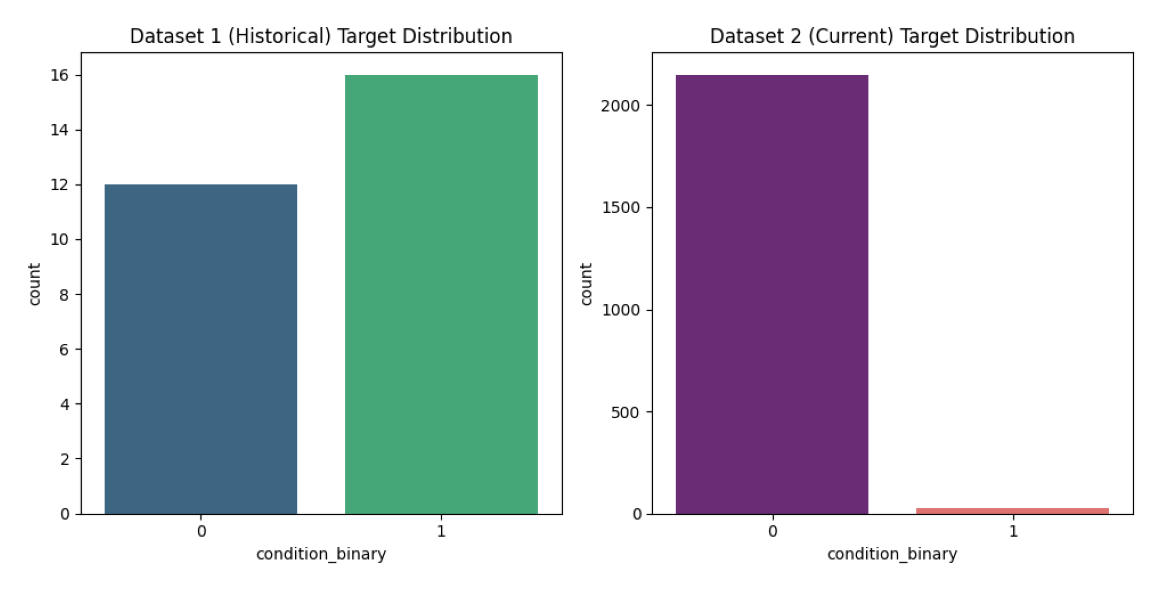


### Feature Distributions (Boxplots)
These boxplots illustrate the distribution of key numerical features across historical and current datasets. They are useful for identifying shifts in feature ranges, medians, and outliers, which might indicate data drift.


📊 Displaying: boxplot_age.png



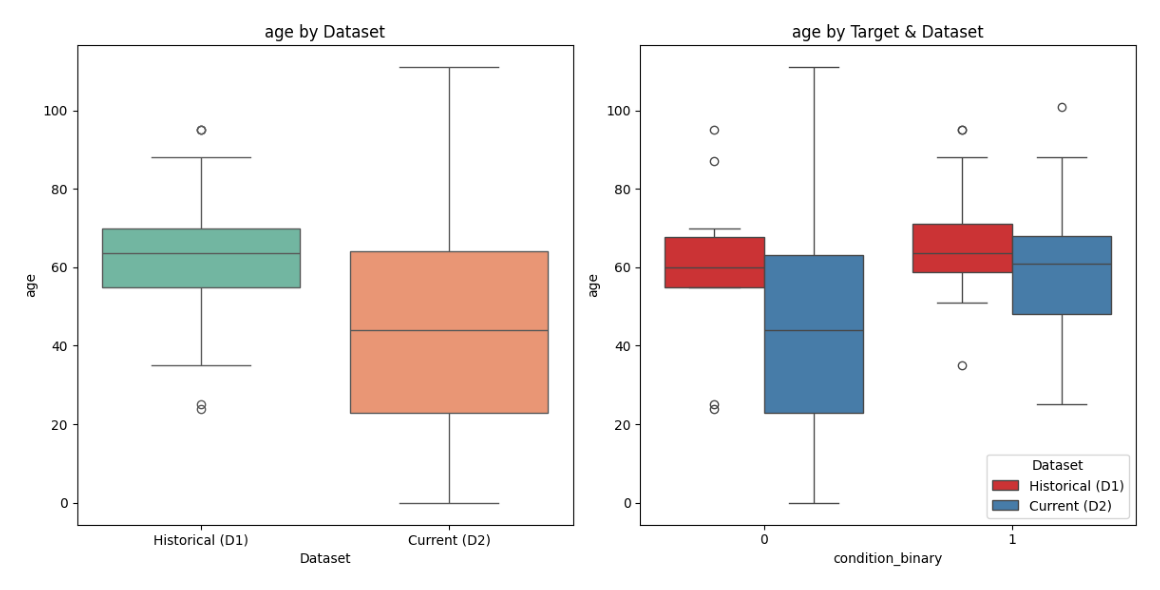


📊 Displaying: boxplot_systolic_blood_pressure_mean.png



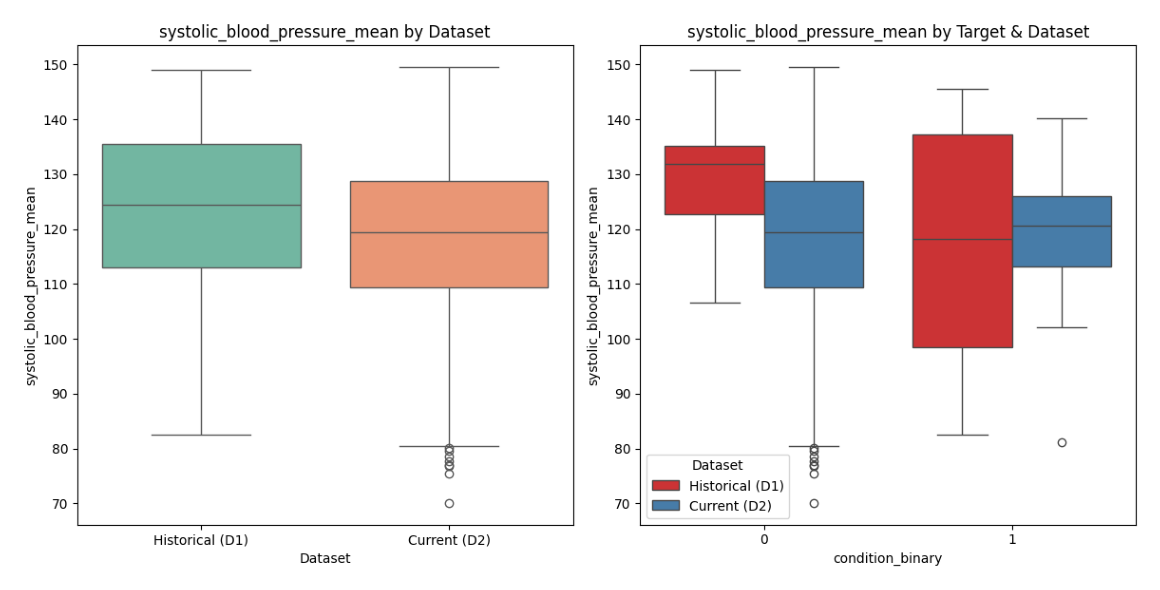


📊 Displaying: boxplot_systolic_blood_pressure_std.png



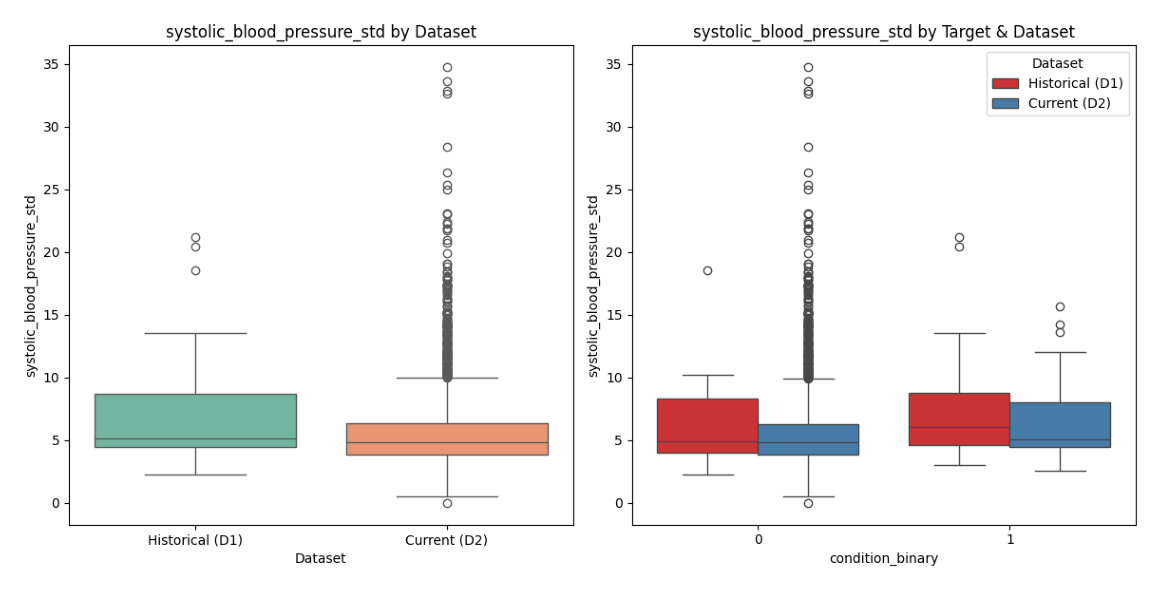


📊 Displaying: boxplot_diastolic_blood_pressure_mean.png



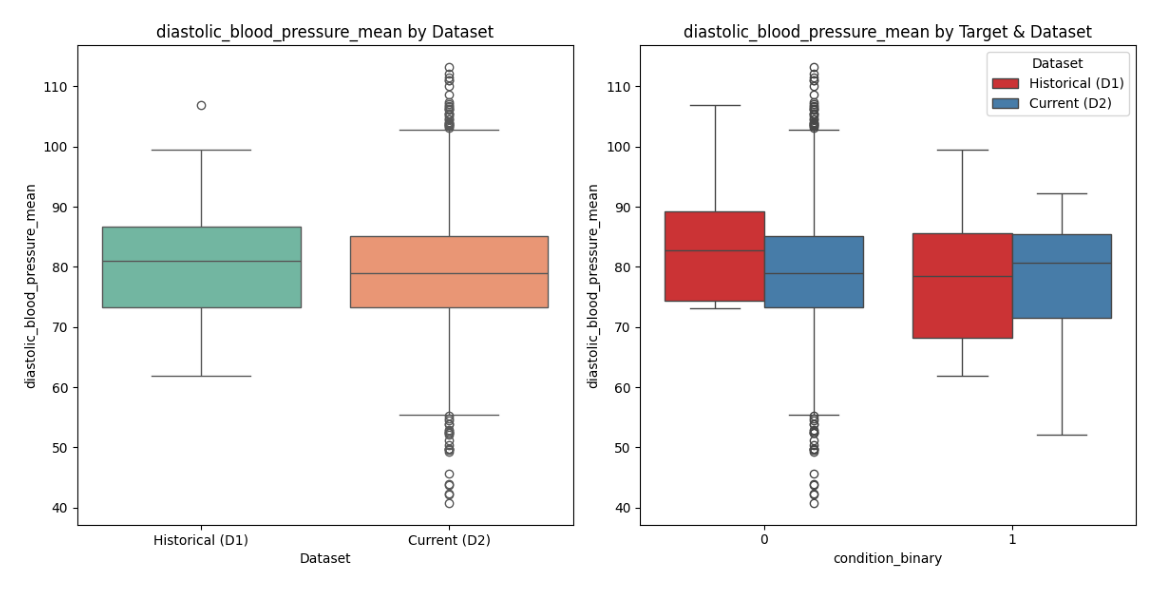


📊 Displaying: boxplot_heart_rate_mean.png



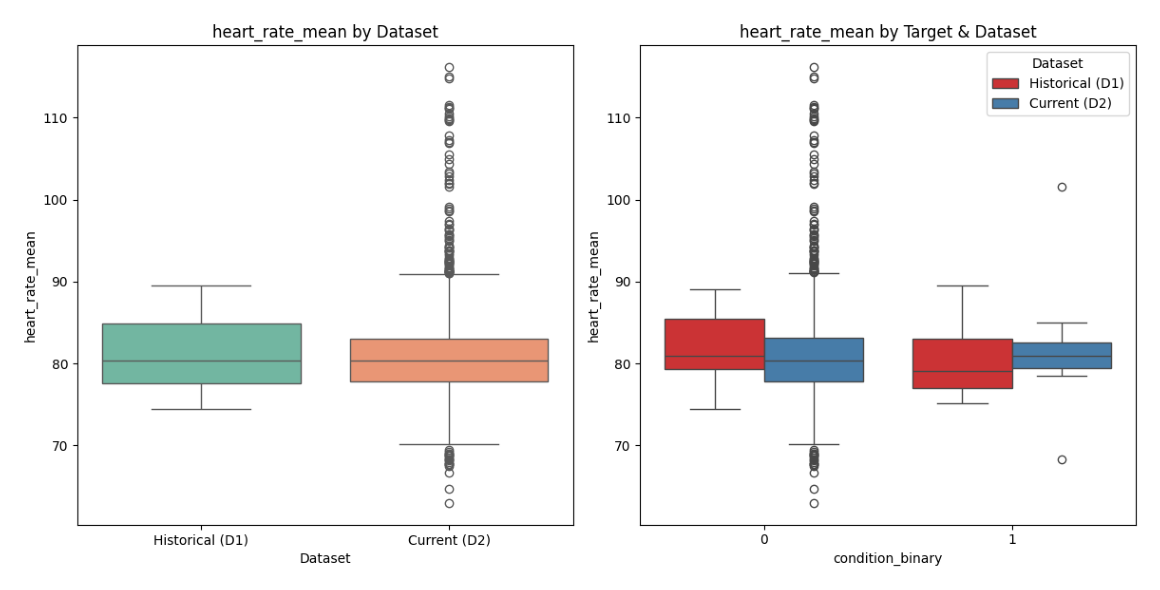


### ROC Curve Comparison
Receiver Operating Characteristic (ROC) curves illustrate the diagnostic ability of binary classifiers as the discrimination threshold is varied. The Area Under the Curve (AUC) provides a single metric for model performance, with higher AUC indicating better discrimination. Comparing ROC curves between D1_Test and D2_Test helps assess how model performance changes with new data.


📊 Displaying: roc_comparison_D1_Test.png



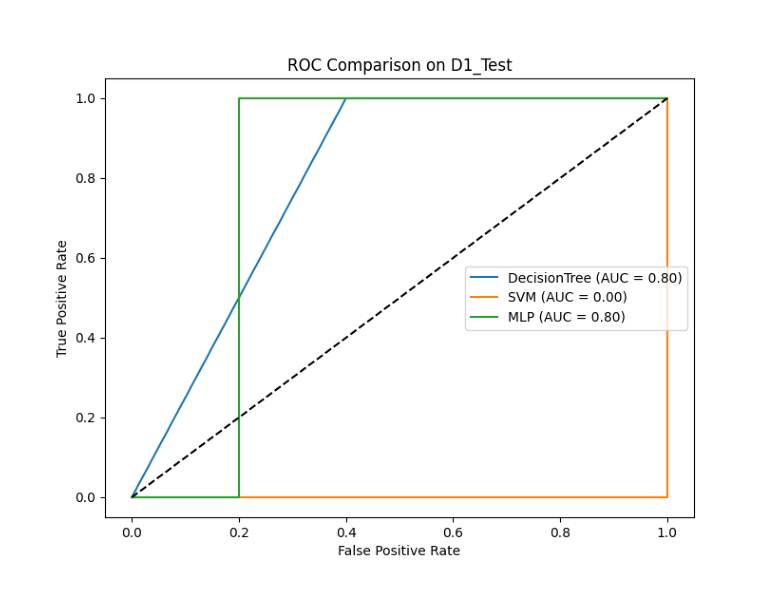


📊 Displaying: roc_comparison_D2_Test.png



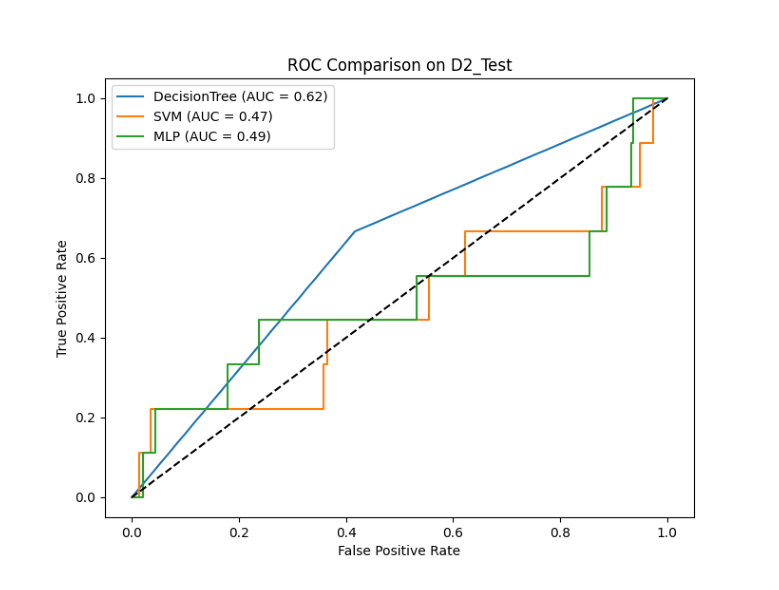


### Feature Importance (XAI)
Feature Importance plots highlight which features contribute most to a model's predictions. Different models calculate importance in various ways. For Decision Trees, it's often based on how much each feature reduces impurity. For other models like MLP, it might be derived from permutation importance or model-specific coefficients. These plots help understand global model behavior.


📊 Displaying: feature_importance_DecisionTree.png



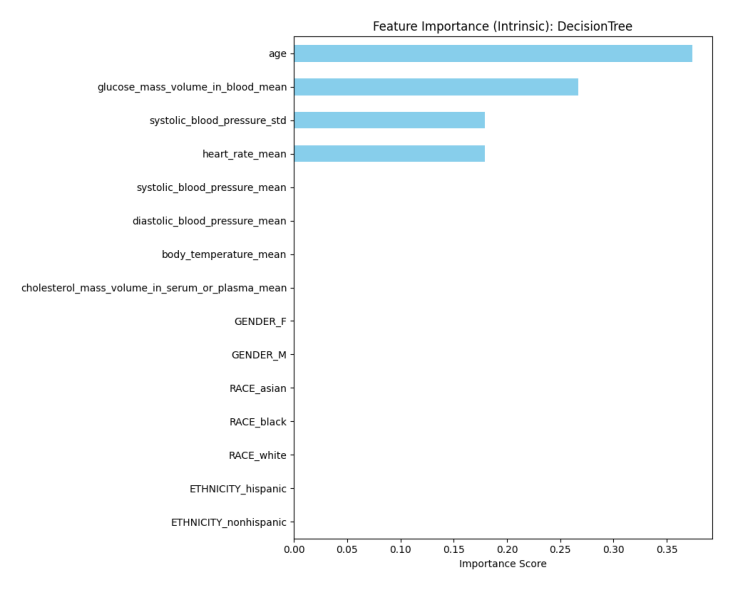


📊 Displaying: feature_importance_SVM.png



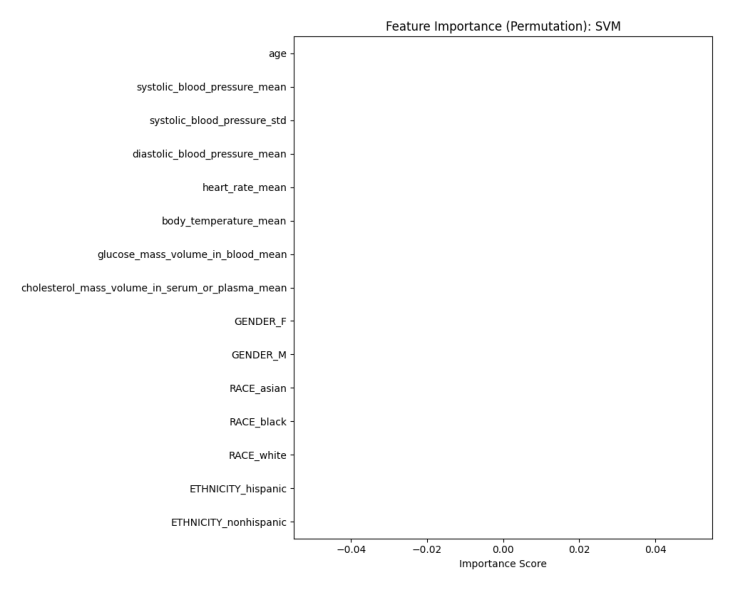


📊 Displaying: feature_importance_MLP.png



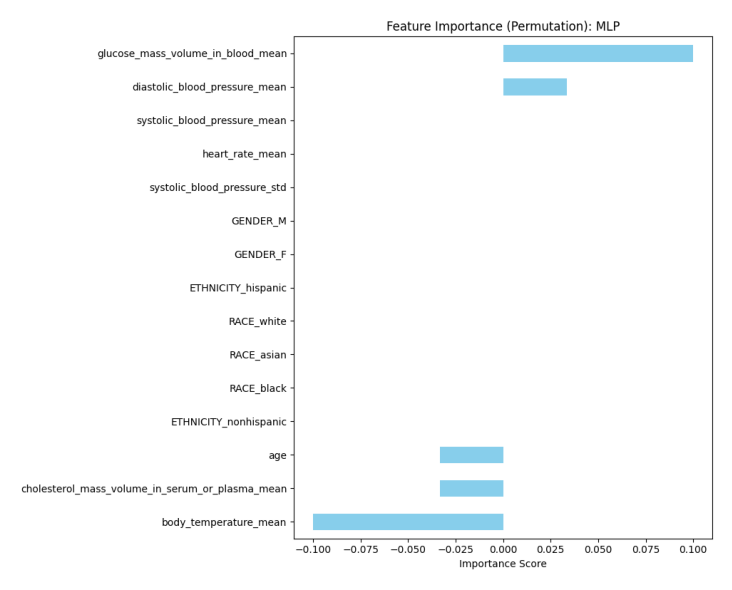


📊 Displaying: feature_importance_MLP_FineTuned.png



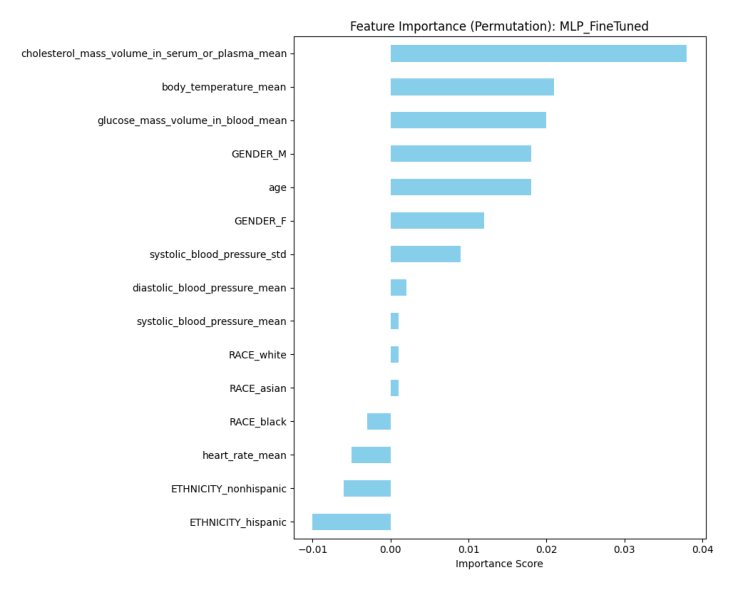


### SHAP Heatmaps (XAI)
SHAP (SHapley Additive exPlanations) values provide a way to explain individual predictions by showing how much each feature contributes to pushing the model's output from the base value to the predicted value. A SHAP heatmap visualizes these contributions across multiple instances, where positive SHAP values indicate features pushing towards a positive prediction, and negative values push towards a negative prediction. This offers local interpretability for model decisions.


📊 Displaying: shap_heatmap_DecisionTree.png



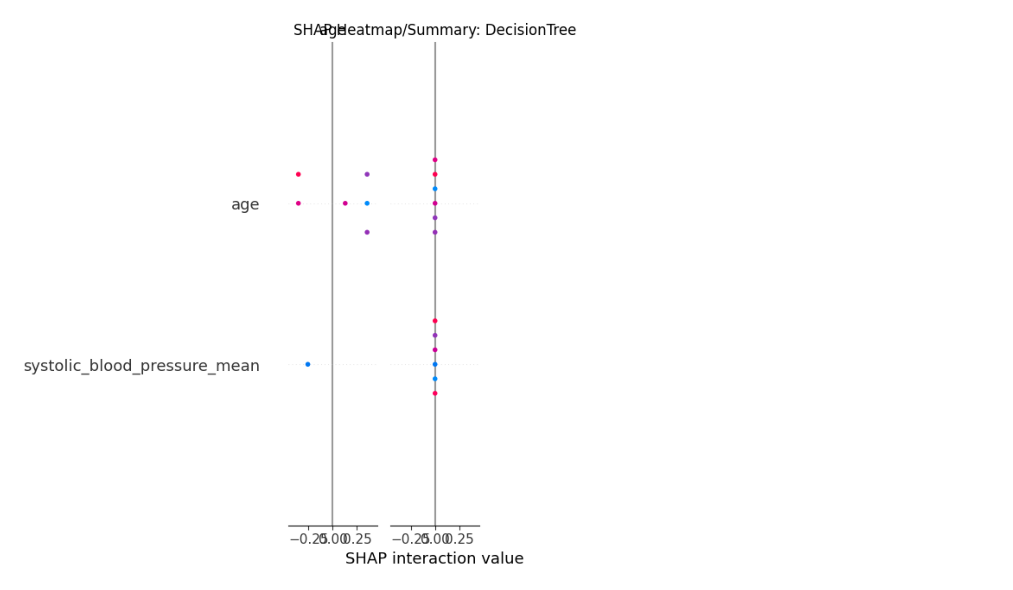


📊 Displaying: shap_heatmap_SVM.png



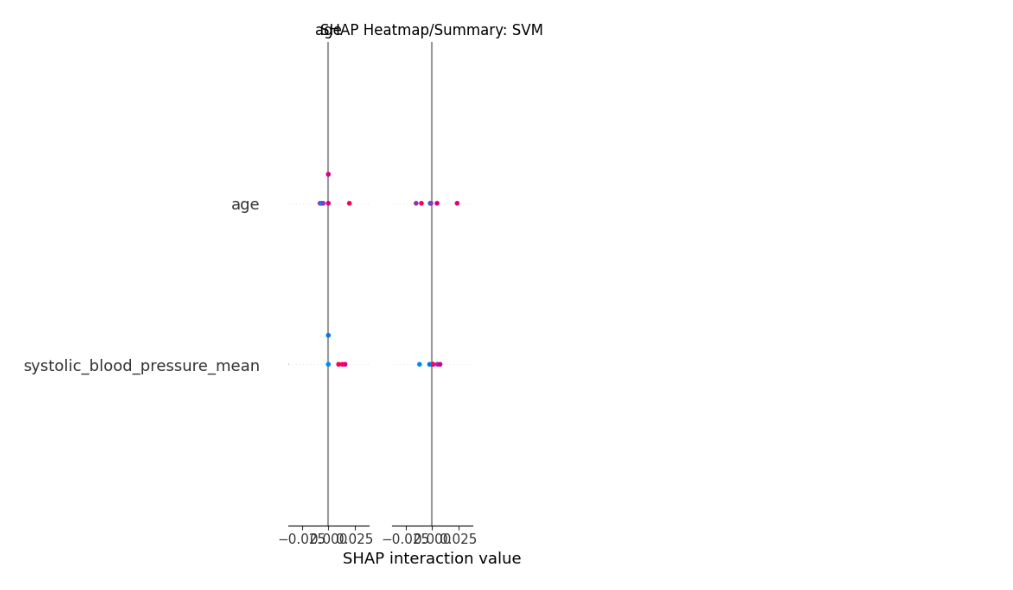


📊 Displaying: shap_heatmap_MLP.png



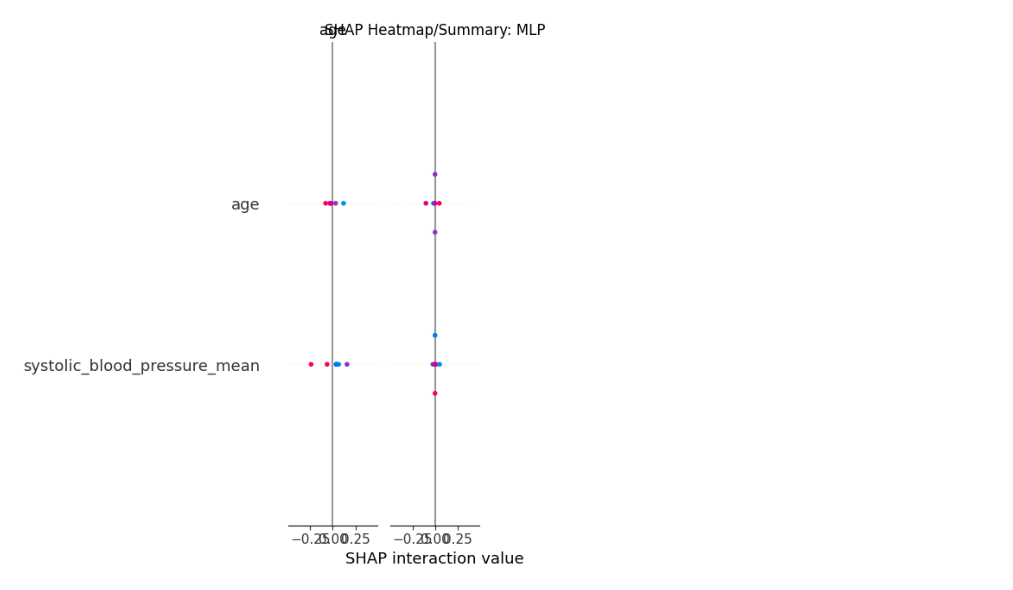


📊 Displaying: shap_heatmap_MLP_FineTuned.png



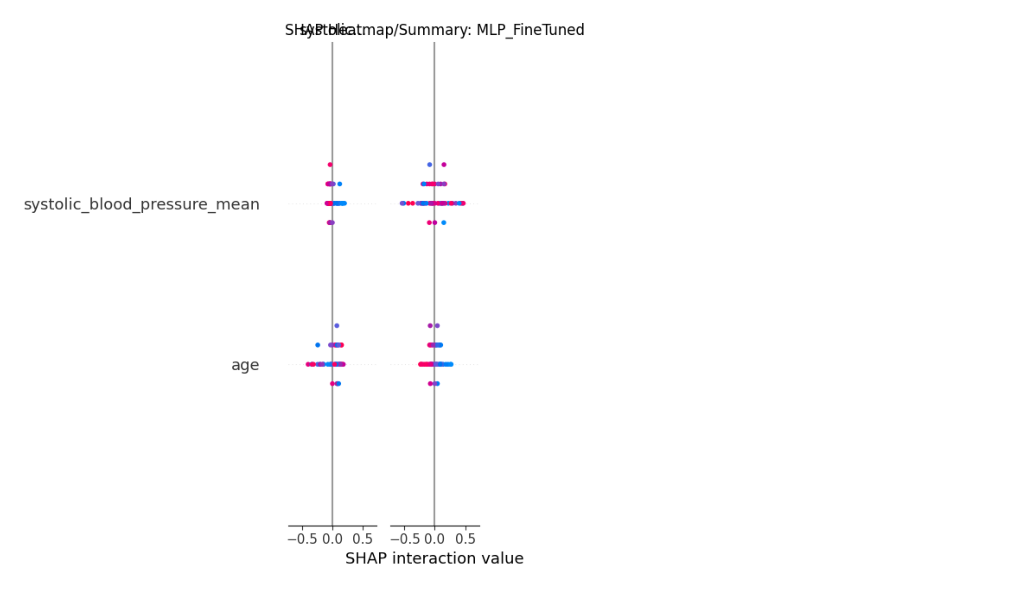


✅ ALL RESULTS AND VISUALIZATIONS DISPLAYED!



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os

# Ensure the current working directory is the project root for consistent pathing
project_root_env = os.environ.get('PROJECT_ROOT_DIR', '/content/ML-Pipeline-and-Dashboard-for-Clinical-Prediction-under-Temporal-Shift-in-EHR-Data_Final/project_root')
if os.getcwd() != project_root_env:
    os.chdir(project_root_env)

project_root = os.getcwd()

print("""
============================================================
LOADING AND DISPLAYING RESULTS
============================================================
""")

# --- Load Data ---
d1 = pd.read_csv(f'{project_root}/data/processed/dataset1_historical.csv')
d2 = pd.read_csv(f'{project_root}/data/processed/dataset2_current.csv')
perf = pd.read_csv(f'{project_root}/reports/model_performance.csv')
drift = pd.read_csv(f'{project_root}/reports/drift_analysis.csv')

print("""
# Data Overview
Below are statistical summaries for the historical (Dataset 1) and current (Dataset 2) data, as well as the model performance and drift analysis reports.
""")

print("""
============================================================
DATASET 1 (Historical) - STATISTICS
============================================================
""")
print(f"Shape: {d1.shape}")
print(f"Target Distribution:\n{d1['condition_binary'].value_counts()}\n")
print("Numerical Feature Summary:")
display(d1.describe())
print("\nFirst few rows:")
display(d1.head())

print("""
============================================================
DATASET 2 (Current) - STATISTICS
============================================================
""")
print(f"Shape: {d2.shape}")
print(f"Target Distribution:\n{d2['condition_binary'].value_counts()}\n")
print("Numerical Feature Summary:")
display(d2.describe())
print("\nFirst few rows:")
display(d2.head())

print("""
============================================================
MODEL PERFORMANCE METRICS
============================================================
""")
print("This table shows the performance metrics (accuracy, precision, recall, F1-score) for different models on both the historical (D1_Test) and current (D2_Test) datasets. It highlights how well each model performed and whether there was a drop in performance on the current data, indicating potential temporal shift.")
display(perf.to_string())

print("""
============================================================
DRIFT ANALYSIS
============================================================
""")
print("The drift analysis report uses the Kolmogorov-Smirnov (KS) test to compare the distributions of features between Dataset 1 (historical) and Dataset 2 (current). A 'drift_detected' value of `True` (typically when p-value < 0.05) indicates a statistically significant change in a feature's distribution, which can impact model performance.")
display(drift.to_string())

print("""
# Visualizations and Explainable AI (XAI)
Below are key visualizations generated by the pipeline, including plots for data distributions, model evaluation (ROC curves), and Explainable AI (XAI) reports such as Feature Importance and SHAP Heatmaps.
""")

reports_dir = f'{project_root}/reports'
images = sorted([f for f in os.listdir(reports_dir) if f.endswith('.png')])

print(f"Found {len(images)} visualization files in {reports_dir}\n")

# Define a dictionary for image categories and their explanations
visualization_sections = {
    "Target Distribution": {
        "explanation": "These plots show the distribution of the target variable ('condition_binary') in both historical and current datasets. This helps visualize if the prevalence of the condition has changed over time.",
        "files": ['target_distribution.png']
    },
    "Feature Distributions (Boxplots)": {
        "explanation": "These boxplots illustrate the distribution of key numerical features across historical and current datasets. They are useful for identifying shifts in feature ranges, medians, and outliers, which might indicate data drift.",
        "files": [
            'boxplot_age.png',
            'boxplot_systolic_blood_pressure_mean.png',
            'boxplot_systolic_blood_pressure_std.png',
            'boxplot_diastolic_blood_pressure_mean.png',
            'boxplot_heart_rate_mean.png'
        ]
    },
    "ROC Curve Comparison": {
        "explanation": "Receiver Operating Characteristic (ROC) curves illustrate the diagnostic ability of binary classifiers as the discrimination threshold is varied. The Area Under the Curve (AUC) provides a single metric for model performance, with higher AUC indicating better discrimination. Comparing ROC curves between D1_Test and D2_Test helps assess how model performance changes with new data.",
        "files": [
            'roc_comparison_D1_Test.png',
            'roc_comparison_D2_Test.png'
        ]
    },
    "Feature Importance (XAI)": {
        "explanation": "Feature Importance plots highlight which features contribute most to a model's predictions. Different models calculate importance in various ways. For Decision Trees, it's often based on how much each feature reduces impurity. For other models like MLP, it might be derived from permutation importance or model-specific coefficients. These plots help understand global model behavior.",
        "files": [
            'feature_importance_DecisionTree.png',
            'feature_importance_SVM.png',
            'feature_importance_MLP.png',
            'feature_importance_MLP_FineTuned.png'
        ]
    },
    "SHAP Heatmaps (XAI)": {
        "explanation": "SHAP (SHapley Additive exPlanations) values provide a way to explain individual predictions by showing how much each feature contributes to pushing the model's output from the base value to the predicted value. A SHAP heatmap visualizes these contributions across multiple instances, where positive SHAP values indicate features pushing towards a positive prediction, and negative values push towards a negative prediction. This offers local interpretability for model decisions.",
        "files": [
            'shap_heatmap_DecisionTree.png',
            'shap_heatmap_SVM.png',
            'shap_heatmap_MLP.png',
            'shap_heatmap_MLP_FineTuned.png'
        ]
    }
}

# Display visualizations by section
for section_title, section_data in visualization_sections.items():
    print(f"""
### {section_title}
{section_data['explanation']}
""")
    for img_file in section_data['files']:
        img_path = os.path.join(reports_dir, img_file)
        if os.path.exists(img_path):
            print(f"""
{'=' * 60}
📊 Displaying: {img_file}
{'=' * 60}
""")
            img = Image.open(img_path)
            plt.figure(figsize=(12, 6))
            plt.imshow(img)
            plt.axis('off')
            plt.tight_layout()
            plt.show()
        else:
            print(f"⚠️ {img_file} not found in {reports_dir}")

print("""
============================================================
✅ ALL RESULTS AND VISUALIZATIONS DISPLAYED!
============================================================
""")


In [ ]:
!streamlit run /content/ML-Pipeline-and-Dashboard-for-Clinical-Prediction-under-Temporal-Shift-in-EHR-Data_Final/project_root/dashboard/dashboard.py &

/bin/bash: line 1: streamlit: command not found


In [ ]:
# Check if dashboard loads data correctly
import os
os.chdir('/content/ML-Pipeline-and-Dashboard-for-Clinical-Prediction-under-Temporal-Shift-in-EHR-Data_Final/project_root')

# Test loading
import pandas as pd
d1 = pd.read_csv('data/processed/dataset1_historical.csv')
print("✅ Data loads successfully!")

FileNotFoundError: [Errno 2] No such file or directory: '/content/ML-Pipeline-and-Dashboard-for-Clinical-Prediction-under-Temporal-Shift-in-EHR-Data_Final/project_root'